# Power Analysis & Experiment Design

**Dataset:** Kevin Hillstrom's MineThatData E-Mail Analytics dataset — 64,000
customers randomized into three arms (Men's e-mail campaign, Women's e-mail
campaign, No e-mail / control), with visit, conversion, and spend tracked over
the following two weeks.

**Goal of this notebook:** demonstrate the judgment a product data scientist
needs *before* and *during* an experiment:

1. **EDA + randomization check** — confirm the three arms are actually
   comparable before trusting any effect estimate.
2. **Power / MDE calculator** — given a baseline rate and traffic, how big
   does a test need to be (or, given a fixed sample size, what's the smallest
   effect we could reliably detect)?
3. **The peeking problem** — why checking a fixed-horizon test repeatedly and
   stopping the moment it looks significant silently inflates the false
   positive rate, using a from-scratch simulation.

Companion writeup: `writeups/power_analysis.md`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import sys
sys.path.append("../src")
from power_analysis import (
    required_sample_size,
    minimum_detectable_effect,
    two_proportion_z_test,
    simulate_peeking,
)

sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = "../writeups/figures"


## 1. EDA & randomization check

Before trusting any A/B result, check that randomization actually balanced
the arms on pre-experiment covariates. If covariates like recency or past
spend differ systematically across arms, something is wrong with the
randomization (or the data pipeline feeding it) and any effect estimate is
suspect.


In [2]:
df = pd.read_csv("../data/raw/hillstrom.csv")
print(df.shape)
df.head()


(64000, 12)


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [3]:
df["segment"].value_counts()


segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

In [4]:
# Randomization check: pre-experiment covariates should be balanced across arms.
# recency, history, mens, womens, newbie are all measured *before* the campaign,
# so under correct randomization their means should be statistically indistinguishable
# across the three arms.
covariates = ["recency", "history", "mens", "womens", "newbie"]
balance = df.groupby("segment")[covariates].mean().T
balance


segment,Mens E-Mail,No E-Mail,Womens E-Mail
recency,5.773642,5.749695,5.767850
history,242.835931,240.882653,242.536633
mens,0.550946,0.553224,0.548932
womens,0.551415,0.547639,0.550101
newbie,0.501525,0.501971,0.503250


In [5]:
# One-way ANOVA per covariate as a quick omnibus check (not a substitute for
# a full pre-registration balance table, but enough to catch a broken
# randomization in a portfolio-scale check).
for cov in covariates:
    groups = [g[cov].values for _, g in df.groupby("segment")]
    f_stat, p_val = stats.f_oneway(*groups)
    flag = "  <-- imbalanced at alpha=0.05" if p_val < 0.05 else ""
    print(f"{cov:10s}  F={f_stat:6.2f}  p={p_val:.3f}{flag}")


recency     F=  0.27  p=0.763
history     F=  0.36  p=0.698
mens        F=  0.40  p=0.672
womens      F=  0.32  p=0.729
newbie      F=  0.07  p=0.934


None of the pre-experiment covariates differ significantly across arms —
randomization looks clean, so differences in `visit`/`conversion`/`spend`
downstream can be attributed to the treatment rather than a confound.

Next, look at outcome rates by arm. `visit` (did the customer visit the site
in the two weeks after the campaign) has a much higher base rate than
`conversion` (did they purchase), which makes it a better metric to use when
illustrating power/MDE trade-offs — the same ideas apply to `conversion`, just
at a much larger required sample size, which is itself a useful thing to see.


In [6]:
outcome_summary = df.groupby("segment")[["visit", "conversion", "spend"]].mean()
outcome_summary


,visit,conversion,spend
segment,,,
Mens E-Mail,0.182757,0.012531,1.422617
No E-Mail,0.106167,0.005726,0.652789
Womens E-Mail,0.151400,0.008837,1.077202


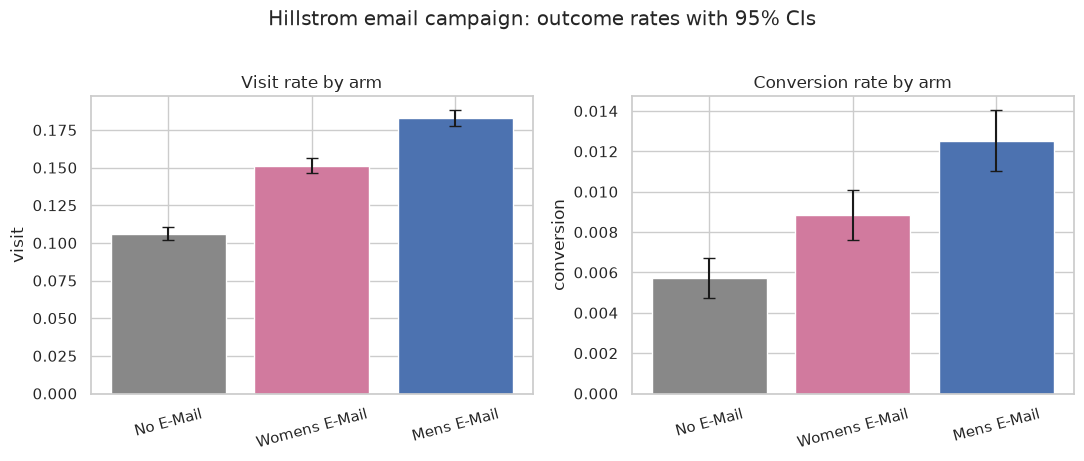

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, metric, title in zip(
    axes, ["visit", "conversion"], ["Visit rate by arm", "Conversion rate by arm"]
):
    rates = df.groupby("segment")[metric].agg(["mean", "count"])
    rates["se"] = np.sqrt(rates["mean"] * (1 - rates["mean"]) / rates["count"])
    rates = rates.reindex(["No E-Mail", "Womens E-Mail", "Mens E-Mail"])
    ax.bar(
        rates.index, rates["mean"], yerr=1.96 * rates["se"],
        capsize=4, color=["#888888", "#d17a9e", "#4c72b0"],
    )
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=15)

fig.suptitle("Hillstrom email campaign: outcome rates with 95% CIs", y=1.02)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/01_outcome_rates_by_arm.png", dpi=150, bbox_inches="tight")
plt.show()


Both campaigns clearly lift visit and conversion rates over control, and the
non-overlapping confidence intervals suggest this isn't noise — but "does it
look different" isn't a substitute for a proper test. That's what the
calculator below is for, applied *prospectively*: given what we knew about
the baseline rate before running this experiment, how large would the sample
need to have been to reliably detect an effect of a given size?


## 2. Power / MDE calculator

Two directions of the same question:

- **"How many users do I need?"** — given a baseline rate and the smallest
  effect worth detecting (the *minimum detectable effect*, MDE), compute the
  required per-arm sample size.
- **"What can I detect?"** — given a sample size I'm stuck with (e.g. a fixed
  traffic budget or launch deadline), compute the smallest effect the test
  can reliably distinguish from noise.

Both use the standard two-proportion z-test power formula (see
`src/power_analysis.py` for the derivation in comments); `required_sample_size`
is cross-checked against `statsmodels.stats.power.NormalIndPower` in
`writeups/power_analysis.md`.


In [8]:
baseline_visit_rate = df.loc[df["segment"] == "No E-Mail", "visit"].mean()
print(f"Observed baseline (control) visit rate: {baseline_visit_rate:.4f}")


Observed baseline (control) visit rate: 0.1062


In [9]:
# Sample size required to detect a range of *relative* lifts on the visit rate,
# at the conventional alpha=0.05 / power=0.80.
relative_lifts = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
rows = []
for lift in relative_lifts:
    mde_abs = baseline_visit_rate * lift
    result = required_sample_size(baseline_visit_rate, mde_abs, alpha=0.05, power=0.80)
    rows.append({
        "relative_lift": f"{lift:.0%}",
        "mde_absolute": round(mde_abs, 4),
        "n_per_variant": result.n_per_variant,
        "n_total": result.n_total,
        "runtime_days_at_5k_users_per_day": round(result.runtime_days(5000), 1),
    })

sample_size_table = pd.DataFrame(rows)
sample_size_table


,relative_lift,mde_absolute,n_per_variant,n_total,runtime_days_at_5k_users_per_day
0,5%,0.0053,54024,108048,21.6
1,10%,0.0106,13794,27588,5.5
2,15%,0.0159,6257,12514,2.5
3,20%,0.0212,3591,7182,1.4
4,30%,0.0319,1658,3316,0.7
5,50%,0.0531,641,1282,0.3


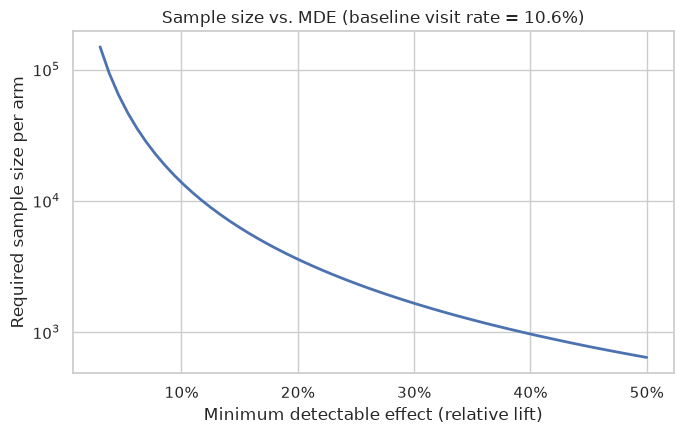

In [10]:
# Classic "power curve": required sample size explodes as the MDE shrinks.
mde_range = np.linspace(baseline_visit_rate * 0.03, baseline_visit_rate * 0.5, 60)
n_required = [
    required_sample_size(baseline_visit_rate, mde, alpha=0.05, power=0.80).n_per_variant
    for mde in mde_range
]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(mde_range / baseline_visit_rate, n_required, color="#4c72b0", linewidth=2)
ax.set_xlabel("Minimum detectable effect (relative lift)")
ax.set_ylabel("Required sample size per arm")
ax.set_title("Sample size vs. MDE (baseline visit rate = {:.1%})".format(baseline_visit_rate))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_yscale("log")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/02_sample_size_vs_mde.png", dpi=150, bbox_inches="tight")
plt.show()


Below roughly a 10% relative lift, required sample size grows very fast — the
classic reason product teams cap how small an MDE they chase: below some
point, "sufficiently powered" starts costing more traffic and calendar time
than the decision is worth.

### Retrospective check: was the actual Hillstrom test well-powered?

The real experiment ran ~21,300 customers per arm. Given the observed control
rate, what MDE was that sample size actually able to detect — and does the
Men's campaign's real effect clear that bar?


In [11]:
actual_n_per_arm = int(df["segment"].value_counts().mean())
achievable_mde = minimum_detectable_effect(baseline_visit_rate, actual_n_per_arm, alpha=0.05, power=0.80)

mens_visit_rate = df.loc[df["segment"] == "Mens E-Mail", "visit"].mean()
observed_effect = mens_visit_rate - baseline_visit_rate

print(f"Actual sample size per arm:        {actual_n_per_arm:,}")
print(f"Achievable MDE (alpha=.05, pow=.8): {achievable_mde:.4f}  ({achievable_mde/baseline_visit_rate:.1%} relative)")
print(f"Observed effect (Men's vs control): {observed_effect:.4f}  ({observed_effect/baseline_visit_rate:.1%} relative)")
print(f"Observed effect clears the MDE bar: {observed_effect > achievable_mde}")


Actual sample size per arm:        21,333
Achievable MDE (alpha=.05, pow=.8): 0.0084  (7.9% relative)
Observed effect (Men's vs control): 0.0766  (72.1% relative)
Observed effect clears the MDE bar: True


In [12]:
# Confirm with a direct significance test on the actual data.
n_control = (df["segment"] == "No E-Mail").sum()
c_control = df.loc[df["segment"] == "No E-Mail", "visit"].sum()
n_mens = (df["segment"] == "Mens E-Mail").sum()
c_mens = df.loc[df["segment"] == "Mens E-Mail", "visit"].sum()

z, p = two_proportion_z_test(n_control, c_control, n_mens, c_mens)
print(f"z = {z:.2f}, p = {p:.2e}")


z = 22.49, p = 0.00e+00


The actual experiment was comfortably well-powered for the effect it found —
the observed lift is well above the MDE the sample size could detect, and the
direct z-test confirms it at a p-value far below any reasonable alpha. That's
the sign of a healthy, well-designed test: the sample size wasn't wasted, and
the result isn't a lucky roll on an underpowered study.


## 3. The peeking problem

A fixed-horizon test controls the false positive rate at `alpha` *only if you
look once*, at the pre-committed sample size. In practice, teams check
dashboards daily and are tempted to stop as soon as the test "turns
green." That practice — checking repeatedly and stopping at the first
significant p-value — inflates the true false positive rate far above the
nominal alpha, even when there is truly no effect.

The simulation below makes this concrete: 3,000 simulated experiments, no
true effect in any of them (`true_effect=0.0`), checked at 20 evenly spaced
points as the sample accumulates.


In [13]:
peek_result = simulate_peeking(
    baseline_rate=baseline_visit_rate,
    n_per_variant_max=4000,
    n_checks=20,
    alpha=0.05,
    n_simulations=3000,
    true_effect=0.0,
    random_state=42,
)

print(f"Fixed-horizon false positive rate (look once, at the end): {peek_result['fixed_horizon_false_positive_rate']:.1%}")
print(f"Peeking false positive rate (stop at first p < .05):       {peek_result['peeking_false_positive_rate']:.1%}")
print(f"Nominal alpha:                                             {peek_result['alpha']:.1%}")


Fixed-horizon false positive rate (look once, at the end): 4.9%
Peeking false positive rate (stop at first p < .05):       24.3%
Nominal alpha:                                             5.0%


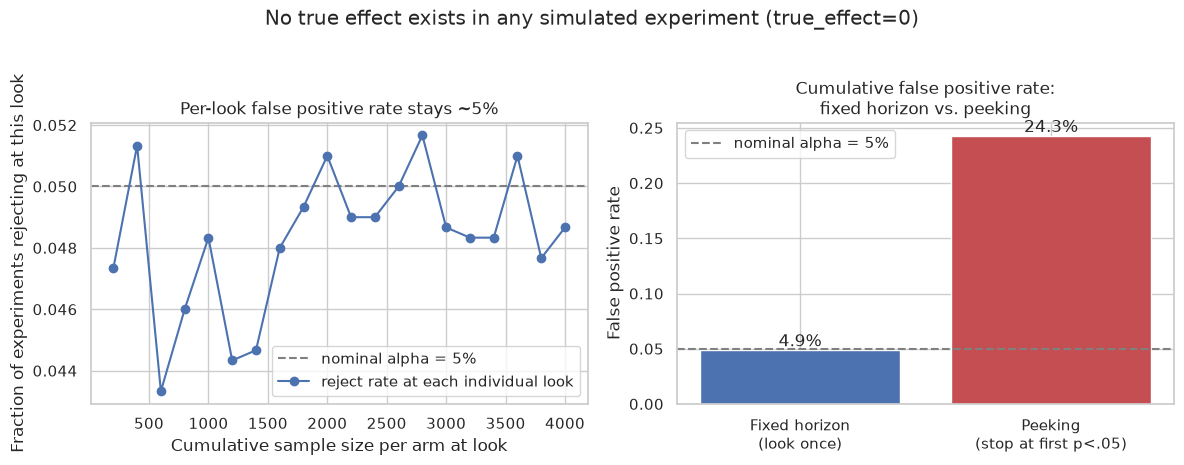

In [14]:
checks = peek_result["check_points"]
per_look = peek_result["per_look_reject_rate"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].axhline(0.05, color="gray", linestyle="--", label="nominal alpha = 5%")
axes[0].plot(checks, per_look, marker="o", color="#4c72b0", label="reject rate at each individual look")
axes[0].set_xlabel("Cumulative sample size per arm at look")
axes[0].set_ylabel("Fraction of experiments rejecting at this look")
axes[0].set_title("Per-look false positive rate stays ~5%")
axes[0].legend()

bars = axes[1].bar(
    ["Fixed horizon\n(look once)", "Peeking\n(stop at first p<.05)"],
    [peek_result["fixed_horizon_false_positive_rate"], peek_result["peeking_false_positive_rate"]],
    color=["#4c72b0", "#c44e52"],
)
axes[1].axhline(0.05, color="gray", linestyle="--", label="nominal alpha = 5%")
axes[1].set_ylabel("False positive rate")
axes[1].set_title("Cumulative false positive rate:\nfixed horizon vs. peeking")
axes[1].bar_label(bars, fmt="{:.1%}")
axes[1].legend()

fig.suptitle("No true effect exists in any simulated experiment (true_effect=0)", y=1.03)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/03_peeking_inflation.png", dpi=150, bbox_inches="tight")
plt.show()


Each *individual* look is well-calibrated — about 5% of experiments are
significant at any single checkpoint, exactly as alpha promises. But because
20 *different* opportunities to stop are being taken across the life of the
test, the chance that *at least one* of them looks significant by chance is
far higher than 5%. This is the same logic as multiple comparisons — every
peek is another independent-ish shot at a false positive.

**Practical takeaways:**

- If you must monitor a test as it runs, decide in advance whether you're
  running a fixed-horizon test (commit to the sample size, don't act on
  interim results) or a genuinely sequential test (use a method designed for
  repeated looks, e.g. group-sequential designs with alpha-spending
  functions like O'Brien-Fleming, or always-valid sequential testing methods).
- "We'll just peek and stop early if it's already significant" is not a free
  shortcut — it's a specific, unstated relaxation of alpha that this
  simulation shows costs roughly 4-5x the nominal false positive rate at 20
  looks.


## Summary

- Verified the Hillstrom randomization is balanced on pre-experiment
  covariates, so the observed campaign effects can be attributed to
  treatment.
- Built a reusable power/MDE calculator (`src/power_analysis.py`) and used it
  both prospectively (sample size needed for a target MDE) and
  retrospectively (confirming the actual Hillstrom sample size was adequate
  to detect the effect it found).
- Demonstrated, via simulation, that stopping a fixed-horizon test at the
  first significant peek inflates the false positive rate several-fold above
  the nominal alpha — a concrete, runnable answer to "why can't we just check
  the dashboard and call it when it looks good."

See `writeups/power_analysis.md` for the fuller write-up.
